# Examen 1er Parcial - INF672 MACHINE LEARNING 

**Nombre:** Eddy Edson Quispe Condori  
**RU:** 120777  


## Ejercicio 1 — Una probabilidad de dos maneras


In [1]:
#Obtecion de 36 resultados posibles 
import itertools
import numpy as np
import pandas as pd

itertools.product(range(1,7), repeat=2)

resultados = list(itertools.product(range(1, 7), repeat=2))

print("Cantidad de resultados posibles:", len(resultados))
print(resultados)

Cantidad de resultados posibles: 36
[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (4, 6), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6)]


In [2]:
#Contar casos con almenos un 6
casos_favorables = [
    par for par in resultados
    if 6 in par
]

print("Casos favorables:", len(casos_favorables))
print(casos_favorables)

Casos favorables: 11
[(1, 6), (2, 6), (3, 6), (4, 6), (5, 6), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6)]


In [3]:
#Calcular la probabilidad exacta 
probabilidad_exacta = len(casos_favorables) / len(resultados)

print("Probabilidad exacta:", probabilidad_exacta)

# Representacion en porcentaje 
print("Probabilidad exacta (%):", probabilidad_exacta * 100)

Probabilidad exacta: 0.3055555555555556
Probabilidad exacta (%): 30.555555555555557


### 1. Interpretación del valor exacto

Al lanzar dos dados existen **36 resultados posibles** (6 × 6). De estos,
**11 resultados contienen al menos un 6**.

Por lo tanto, la probabilidad de obtener al menos un 6 es:

$$
P(\text{al menos un 6}) = \frac{11}{36} \approx 0.3056 = 30.56\%
$$

Esto significa que, al lanzar dos dados, existe aproximadamente un **30.56% de
probabilidad de que al menos uno de los dos dados muestre un 6**.

El resultado exacto permite conocer la probabilidad teórica y compararla con
la probabilidad obtenida mediante una simulación.

In [4]:
# Generador de números aleatorios
rng = np.random.default_rng(42)

# Simulación con 100 lanzamientos
N = 100

tiradas = rng.integers(1, 7, size=(N, 2))
tiene_seis = np.any(tiradas == 6, axis=1)

estimacion = tiene_seis.mean()

print("Estimación de la probabilidad:", estimacion)
print("Estimación en porcentaje:", estimacion * 100, "%")




Estimación de la probabilidad: 0.24
Estimación en porcentaje: 24.0 %


In [5]:
# Simulación con 1000 lanzamientos
N = 1000

tiradas = rng.integers(1, 7, size=(N, 2))

tiene_seis = np.any(tiradas == 6, axis=1)

estimacion_1000 = tiene_seis.mean()

print("Estimación de la probabilidad:", estimacion_1000)
print("Estimación en porcentaje:", estimacion_1000 * 100, "%")


Estimación de la probabilidad: 0.31
Estimación en porcentaje: 31.0 %


In [6]:
# Simulación con 100000 lanzamientos
N = 100000

tiradas = rng.integers(1, 7, size=(N, 2))

tiene_seis = np.any(tiradas == 6, axis=1)

estimacion_1000 = tiene_seis.mean()

print("Estimación de la probabilidad:", estimacion_1000)
print("Estimación en porcentaje:", estimacion_1000 * 100, "%")

Estimación de la probabilidad: 0.30583
Estimación en porcentaje: 30.583 %


In [7]:
# Crear tabla de comparacion

datos = {
    "N": [100, 1000, 100000],
    "Estimacion": [0.24, 0.31, 0.30583]
}

tabla = pd.DataFrame(datos)

tabla["Error absoluto"] = abs(tabla["Estimacion"] - probabilidad_exacta)

tabla

,N,Estimacion,Error absoluto
0,100,0.24000,0.065556
1,1000,0.31000,0.004444
2,100000,0.30583,0.000274



### ¿Cuál se acercó más al valor exacto y por qué?

En la simulación realizada, la estimación con **N = 100 000 lanzamientos** fue la
que más se acercó al valor exacto de **0.3056 (30.56%)**. Esto se debe a que al
aumentar el número de lanzamientos se reducen las variaciones producidas por el
azar y la estimación tiende a acercarse a la probabilidad teórica.

### ¿Qué le pasa a la estimación cuando tienes pocas tiradas?

Cuando se realizan pocas tiradas, la estimación puede alejarse más del valor
exacto y presentar mayores variaciones. Esto ocurre porque el azar tiene una
mayor influencia en los resultados cuando el número de lanzamientos es pequeño.

Por lo tanto, **a mayor número de lanzamientos, la estimación tiende a ser más
estable y cercana al valor teórico**.

## Ejercicio 2 — Perfil estadistico por especie y limpieza de datos 




In [8]:
#Cargar datos

import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

# Cargar los datos Iris
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
)

# Agregar la especie
df['especie'] = [iris.target_names[i] for i in iris.target]

df.head()

,sepal_length,sepal_width,petal_length,petal_width,especie
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Estadisticas descriptivas por especie.

Se calculará la **media, mediana, desviación estándar y los cuartiles (Q1, Q2 y Q3)** de las características de las flores para cada especie.

Esto permitirá observar las diferencias entre las especies, conocer la distribución de sus medidas y comparar qué características presentan mayores diferencias.

También se podrá identificar qué característica puede ser más útil para diferenciar las especies y cuáles presentan valores más parecidos entre ellas.
### Medidas utilizadas

- **Media:** representa el valor promedio de los datos.
- **Mediana:** representa el valor central de los datos ordenados.
- **Desviación estándar:** permite observar qué tan dispersos están los datos respecto a la media.
- **Q1:** indica el valor por debajo del cual se encuentra aproximadamente el 25% de los datos.
- **Q2:** corresponde a la mediana y representa el 50% de los datos.
- **Q3:** indica el valor por debajo del cual se encuentra aproximadamente el 75% de los datos.

In [9]:
# Estadísticas por especie y característica

caracteristicas = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]

filas = []

for especie, grupo in df.groupby("especie"):
    for caracteristica in caracteristicas:
        datos = grupo[caracteristica]

        filas.append([
            especie,
            caracteristica,
            datos.mean(),
            datos.median(),
            datos.std(),
            datos.quantile(0.25),
            datos.quantile(0.50),
            datos.quantile(0.75)
        ])

estadisticas = pd.DataFrame(filas, columns=[
    "Especie",
    "Característica",
    "Media",
    "Mediana",
    "Desviación estándar",
    "Q1",
    "Q2",
    "Q3"
])

# Redondear los valores
estadisticas = estadisticas.round(3)

estadisticas

,Especie,Característica,Media,Mediana,Desviación estándar,Q1,Q2,Q3
0,setosa,sepal_length,5.006,5.00,0.352,4.800,5.00,5.200
1,setosa,sepal_width,3.428,3.40,0.379,3.200,3.40,3.675
2,setosa,petal_length,1.462,1.50,0.174,1.400,1.50,1.575
3,setosa,petal_width,0.246,0.20,0.105,0.200,0.20,0.300
4,versicolor,sepal_length,5.936,5.90,0.516,5.600,5.90,6.300
5,versicolor,sepal_width,2.770,2.80,0.314,2.525,2.80,3.000
6,versicolor,petal_length,4.260,4.35,0.470,4.000,4.35,4.600
7,versicolor,petal_width,1.326,1.30,0.198,1.200,1.30,1.500
8,virginica,sepal_length,6.588,6.50,0.636,6.225,6.50,6.900
9,virginica,sepal_width,2.974,3.00,0.322,2.800,3.00,3.175


### 1. Lectura

Al observar las medias de las características por especie, la característica que
parece separar mejor las tres especies es **petal_length**.

Sus medias son 1.462 para `setosa`, 4.260 para `versicolor` y 5.552 para
`virginica`. Se observa una diferencia clara entre las tres especies, por lo
que esta característica permite distinguirlas mejor.

En cambio, **sepal_width** parece ser la característica que más puede confundir.
Sus medias son 3.428 para `setosa`, 2.770 para `versicolor` y 2.974 para
`virginica`. En particular, las medias de `versicolor` y `virginica` son
bastante parecidas.

Por lo tanto, según las medias observadas, `petal_length` parece ser más útil
para separar las especies, mientras que `sepal_width` presenta mayor
posibilidad de confusión entre algunas de ellas.


In [10]:
# Crear una copia del DataFrame
df_nan = df.copy()

# Semilla fija para que los valores sean siempre los mismos
np.random.seed(42)

# Agregar 3 valores faltantes en cada característica
for columna in caracteristicas:
    indices = np.random.choice(df_nan.index, size=3, replace=False)
    df_nan.loc[indices, columna] = np.nan

# Contar los valores faltantes
print("Valores faltantes antes de imputar:")
print(df_nan.isna().sum())

Valores faltantes antes de imputar:
sepal_length    3
sepal_width     3
petal_length    3
petal_width     3
especie         0
dtype: int64


In [11]:
# Imputar los valores faltantes con la mediana de cada especie
for columna in caracteristicas:
    df_nan[columna] = df_nan.groupby("especie")[columna].transform(
        lambda x: x.fillna(x.median())
    )

# Comprobar que ya no existen valores faltantes
print("Valores faltantes después de imputar:")
print(df_nan.isna().sum())

Valores faltantes después de imputar:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
especie         0
dtype: int64


### 3. Faltantes

Se agregaron 3 valores faltantes en cada una de las cuatro características del
conjunto de datos. Antes de realizar la imputación, se encontraron 3 valores
faltantes en `sepal_length`, `sepal_width`, `petal_length` y `petal_width`.

Para completar estos datos se utilizó la **mediana de cada caracteristica por
especie**. Después de realizar la imputación, todas las columnas presentan
0 valores faltantes, por lo que el conjunto de datos quedo completo.
### ¿Por que se prefiere la mediana a la media?

Se prefiere la mediana porque es menos sensible a valores extremos. Si existen
datos muy altos o muy bajos, estos pueden afectar considerablemente a la media,
mientras que la mediana mantiene mejor la representacion del valor central.

Ademas, al calcular la mediana por especie, cada valor faltante se reemplaza
utilizando información de la misma especie, en lugar de utilizar un unico valor
para todo el conjunto de datos.

### ¿Por qué una característica con medias muy distintas entre especies separa mejor que una con medias parecidas?

Una característica con medias muy distintas permite separar mejor las especies
porque sus valores tienden a encontrarse en rangos diferentes. Esto facilita
distinguir una especie de otra.

En cambio, cuando las medias son parecidas, los valores de las diferentes
especies pueden encontrarse en rangos similares, haciendo más difícil
diferenciarlas.

En este caso, `petal_length` tiene medias bastante diferentes entre las tres
especies, mientras que `sepal_width` tiene medias más cercanas. Por eso,
`petal_length` permite una mejor separación de las especies.

## Ejercicio 3 — Tres formas de comparar 2 flores 

In [12]:
# Función para calcular la distancia euclidiana
def distancia_euclidiana(a, b):
    return np.sqrt(np.sum((a - b) ** 2))


# Función para calcular el producto punto
def producto_punto(a, b):
    return np.sum(a * b)


# Función para calcular la similitud coseno
def similitud_coseno(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [13]:
#Seleccionamos 4 flores

# Índices de las cuatro flores seleccionadas
indices = [0, 1, 50, 100]

# Mostrar las flores seleccionadas
df.loc[indices]

,sepal_length,sepal_width,petal_length,petal_width,especie
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
100,6.3,3.3,6.0,2.5,virginica


### 2. Selección de las flores

Para realizar las comparaciones se seleccionaron cuatro flores del conjunto
de datos Iris:

- **Índice 0:** especie `setosa`
- **Índice 1:** especie `setosa`
- **Índice 50:** especie `versicolor`
- **Índice 100:** especie `virginica`

Los índices 0 y 1 corresponden a flores de la misma especie, mientras que los
índices 50 y 100 corresponden a especies diferentes.

In [14]:
# Obtener los vectores de características de las cuatro flores
flores = df.loc[indices, caracteristicas].values

flores

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [7. , 3.2, 4.7, 1.4],
       [6.3, 3.3, 6. , 2.5]])

In [15]:
# Pares de flores que vamos a comparar
pares = [
    (0, 1),
    (0, 50),
    (0, 100),
    (1, 50),
    (1, 100),
    (50, 100)
]

In [16]:
resultados = []

for indice_a, indice_b in pares:
    
    a = df.loc[indice_a, caracteristicas].values
    b = df.loc[indice_b, caracteristicas].values
    
    distancia = distancia_euclidiana(a, b)
    producto = producto_punto(a, b)
    coseno = similitud_coseno(a, b)
    
    resultados.append([
        indice_a,
        df.loc[indice_a, "especie"],
        indice_b,
        df.loc[indice_b, "especie"],
        distancia,
        producto,
        coseno
    ])

comparaciones = pd.DataFrame(resultados, columns=[
    "Índice A",
    "Especie A",
    "Índice B",
    "Especie B",
    "Distancia euclidiana",
    "Producto punto",
    "Similitud coseno"
])

comparaciones.round(4)

,Índice A,Especie A,Índice B,Especie B,Distancia euclidiana,Producto punto,Similitud coseno
0,0,setosa,1,setosa,0.5385,37.49,0.9986
1,0,setosa,50,versicolor,4.0037,53.76,0.9284
2,0,setosa,100,virginica,5.2849,52.58,0.8601
3,1,setosa,50,versicolor,4.0963,50.76,0.9400
4,1,setosa,100,virginica,5.3385,49.67,0.8713
5,50,versicolor,100,virginica,1.8439,86.36,0.9821


## 4. Interpretación de los resultados

Al comparar las cuatro flores mediante la distancia euclidiana, el producto punto
y la similitud coseno, se pueden observar diferentes formas de medir qué tan
parecidas son.

Las flores de la misma especie, como los índices **0 y 1** (`setosa`), presentan
una distancia euclidiana pequeña y una similitud coseno cercana a 1, lo que indica
que sus características son bastante parecidas.

Entre flores de especies diferentes, la distancia euclidiana generalmente aumenta
y la similitud coseno disminuye. Esto permite observar diferencias entre las
características de las flores.

Sin embargo, las tres medidas no representan exactamente el mismo tipo de
comparación. La distancia euclidiana considera directamente la diferencia entre
los valores de las características, mientras que el producto punto y la
similitud coseno trabajan con la relación entre los vectores.

### ¿Las flores de la misma especie salieron "más parecidas"?

Sí. Las flores de la misma especie que se seleccionaron, los índices **0 y 1**
de `setosa`, presentan una distancia euclidiana pequeña y una similitud coseno
muy cercana a 1. Esto indica que sus características son similares.

En comparación, algunos pares de especies diferentes presentan una distancia
mayor y una similitud coseno menor.

### ¿La distancia euclidiana y la similitud coseno ordenan las flores igual?

No necesariamente. Las dos medidas analizan la similitud desde perspectivas
diferentes.

La **distancia euclidiana** mide qué tan separados están los valores de dos
flores, por lo que una distancia menor indica mayor cercanía.

La **similitud coseno** compara principalmente la dirección de los vectores.
Un valor cercano a 1 indica que los vectores tienen una dirección muy similar.

Por esta razón, dos pares de flores pueden tener un orden diferente dependiendo
de la medida utilizada.

## Ejercicio 4 — Bajar la colina: Descenso de gradiente


In [17]:
def descenso_gradiente(tasa, pasos):
    x = 10
    trayectoria = [x]

    for i in range(pasos):
        derivada = 2 * (x - 4)
        x = x - tasa * derivada
        trayectoria.append(x)

    return trayectoria

In [18]:
pasos = 30

trayectoria_001 = descenso_gradiente(0.01, pasos)
trayectoria_01 = descenso_gradiente(0.1, pasos)
trayectoria_11 = descenso_gradiente(1.1, pasos)

print("Tasa 0.01:", trayectoria_001[-1])
print("Tasa 0.1:", trayectoria_01[-1])
print("Tasa 1.1:", trayectoria_11[-1])

Tasa 0.01: 7.272905916294624
Tasa 0.1: 4.007427640235712
Tasa 1.1: 1428.2578827986254


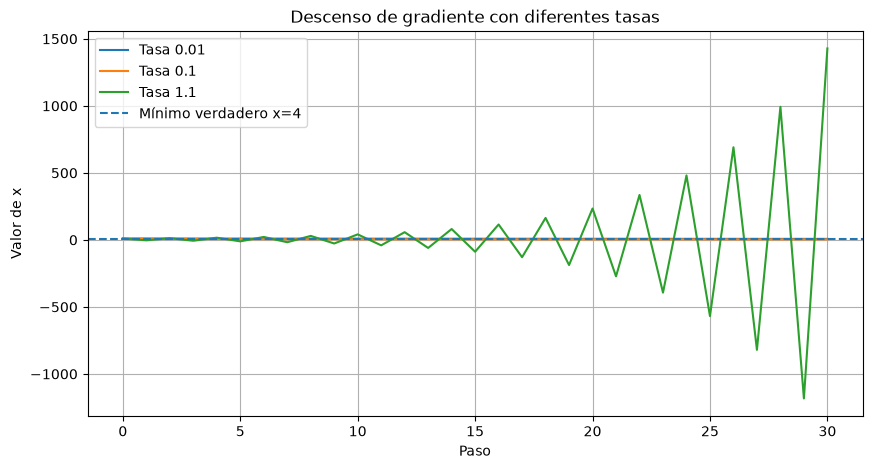

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(trayectoria_001, label="Tasa 0.01")
plt.plot(trayectoria_01, label="Tasa 0.1")
plt.plot(trayectoria_11, label="Tasa 1.1")

plt.axhline(4, linestyle="--", label="Mínimo verdadero x=4")

plt.xlabel("Paso")
plt.ylabel("Valor de x")
plt.title("Descenso de gradiente con diferentes tasas")
plt.legend()
plt.grid()

plt.show()

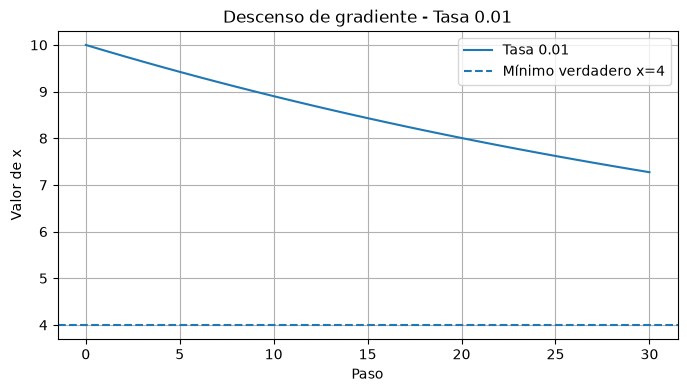

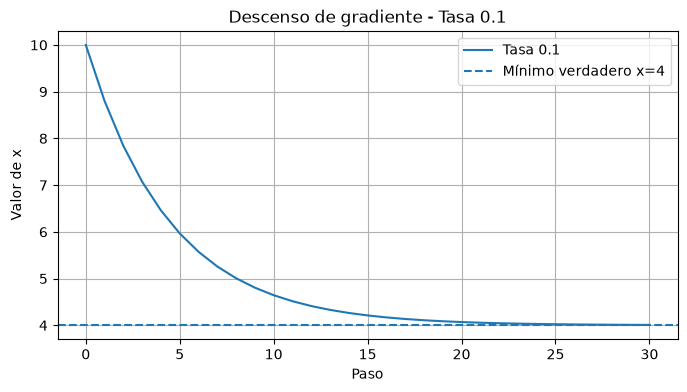

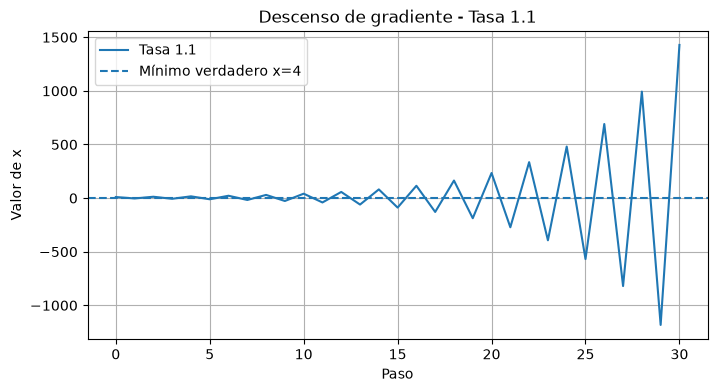

In [26]:
import matplotlib.pyplot as plt

# Tasa 0.01
plt.figure(figsize=(8, 4))
plt.plot(trayectoria_001, label="Tasa 0.01")
plt.axhline(4, linestyle="--", label="Mínimo verdadero x=4")
plt.xlabel("Paso")
plt.ylabel("Valor de x")
plt.title("Descenso de gradiente - Tasa 0.01")
plt.legend()
plt.grid()
plt.show()


# Tasa 0.1
plt.figure(figsize=(8, 4))
plt.plot(trayectoria_01, label="Tasa 0.1")
plt.axhline(4, linestyle="--", label="Mínimo verdadero x=4")
plt.xlabel("Paso")
plt.ylabel("Valor de x")
plt.title("Descenso de gradiente - Tasa 0.1")
plt.legend()
plt.grid()
plt.show()


# Tasa 1.1
plt.figure(figsize=(8, 4))
plt.plot(trayectoria_11, label="Tasa 1.1")
plt.axhline(4, linestyle="--", label="Mínimo verdadero x=4")
plt.xlabel("Paso")
plt.ylabel("Valor de x")
plt.title("Descenso de gradiente - Tasa 1.1")
plt.legend()
plt.grid()
plt.show()

In [20]:
# Comparar los valores finales con el mínimo verdadero
x_minimo = 4

comparacion = pd.DataFrame({
    "Tasa": [0.01, 0.1, 1.1],
    "x final": [
        trayectoria_001[-1],
        trayectoria_01[-1],
        trayectoria_11[-1]
    ]
})

comparacion["Diferencia respecto a x=4"] = abs(
    comparacion["x final"] - x_minimo
)

comparacion.round(4)

,Tasa,x final,Diferencia respecto a x=4
0,0.01,7.2729,3.2729
1,0.10,4.0074,0.0074
2,1.10,1428.2579,1424.2579


### 1. Comparación e interpretación

El mínimo verdadero de la función se encuentra en **x = 4**.

Al comparar los resultados obtenidos, se observa que la tasa de aprendizaje
**0.1** llega muy cerca del mínimo, obteniendo un valor final de aproximadamente
**4.0074**.

La tasa **0.01** también avanza hacia el mínimo, pero después de 30 pasos llega
solamente hasta aproximadamente **7.2729**. Esto demuestra que una tasa muy
pequeña hace que el descenso de gradiente avance lentamente.

En cambio, la tasa **1.1** produce un comportamiento inestable. El valor de x
se aleja cada vez más del mínimo y llega aproximadamente a **1428.2579**. Esto
ocurre porque la tasa de aprendizaje es demasiado grande y provoca que el
algoritmo se pase del mínimo y termine divergiendo.

### ¿Todas llegan cerca del mínimo?

No. La tasa **0.1** llega muy cerca del mínimo verdadero `x = 4`. La tasa
`0.01` también se dirige hacia el mínimo, pero avanza lentamente y después de
30 pasos todavía está lejos. La tasa `1.1` no llega al mínimo, sino que se
aleja y termina divergiendo.

### ¿Qué pasa con la tasa muy pequeña?

La tasa `0.01` produce un avance lento. En cada paso, el cambio de `x` es
pequeño, por lo que necesita muchos más pasos para acercarse al mínimo.

### ¿Qué pasa con la tasa muy grande?

La tasa `1.1` es demasiado grande para esta función. El algoritmo sobrepasa
el mínimo y comienza a alejarse cada vez más. En este caso, el valor de `x`
crece rápidamente y el descenso de gradiente diverge.

### ¿Qué podemos concluir?

La tasa de aprendizaje debe tener un valor adecuado. Una tasa demasiado pequeña
hace que el aprendizaje sea lento, mientras que una tasa demasiado grande puede
hacer que el algoritmo sea inestable y diverja. En este ejercicio, la tasa
`0.1` consigue acercarse rápidamente al mínimo `x = 4`.